In [110]:
# import sys
# !{sys.executable} -m pip install seaborn

In [31]:
import pandas as pd

metadata_df = pd.read_parquet("../data/movies_scraped.parquet")
metadata_df.head()

,id,title,rating,vote_count,genre_ids,keyword_ids,poster_local,year
0,434358,Belle and Sebastian 3: The Last Chapter,6.5,187,"[12, 10751]","[15162, 158416, 160175]",posters\434358.jpg,2018
1,513343,Soldier Millions,5.3,7,"[10752, 18]",[2504],posters\513343.jpg,2018
2,512273,Engine Sentai Go-Onger: 10 Years Grand Prix,8.0,4,"[28, 12, 878]","[9715, 9824, 33637, 155030, 232904, 283547, 31...",posters\512273.jpg,2018
3,689954,Princess Diana: A Life After Death,0.0,0,[99],[300091],posters\689954.jpg,2018
4,603345,The Martyr Maker,5.8,5,[53],[],posters\603345.jpg,2018


In [32]:
poster_paths = (
    metadata_df["poster_local"]
    .dropna()          # remove rows with no poster
    .unique()          # remove duplicates
    .tolist()
)

print(f"{len(poster_paths)} posters found")

1369 posters found


In [17]:
%run FeatureIdentifier.ipynb

C:\Users\Asher\anaconda3\envs\posterbn\python.exe
True
NVIDIA GeForce RTX 3090 Ti


In [18]:
# import json

# poster_path = "eeaaoposter.jpg"
# nodes = extract_poster_nodes(poster_path)

# nodes_print = dict(nodes)
# if isinstance(nodes_print.get("clip_embedding"), np.ndarray):
#     emb = nodes_print["clip_embedding"]
#     nodes_print["clip_embedding"] = {
#         "dim": int(emb.shape[0]),
#         "l2_norm": float(np.linalg.norm(emb)),
#         "preview": emb[:8].round(4).tolist(),
#     }

# print(json.dumps(nodes_print, indent=2))

In [23]:
initialize_feature_models()

device: cuda
yolo: ok
easyocr: ok
mediapipe_face: ok
clip: ok
opennsfw2: ok


{'device': 'cuda',
 'yolo': 'ok',
 'easyocr': 'ok',
 'mediapipe_face': 'ok',
 'clip': 'ok',
 'opennsfw2': 'ok'}

In [24]:
all_results = []
for p in poster_paths:
    try:
        all_results.append(extract_poster_nodes(p))
    except Exception as e:
        all_results.append({"path": p, "extract_error": str(e)})

In [28]:
def flatten_dict(d, parent_key="", sep="."):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else str(k)
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def simplify_row_for_df(row: dict) -> dict:
    out = {}
    for k, v in row.items():
        if k == "clip_embedding":
            # skip raw embedding for first BN
            continue
        elif isinstance(v, np.ndarray):
            out[k] = json.dumps(v.tolist())
        elif isinstance(v, list):
            out[k] = json.dumps(v)
        else:
            out[k] = v
    return out


flat_rows = []
for r in all_results:
    flat = flatten_dict(r)
    flat = simplify_row_for_df(flat)
    flat_rows.append(flat)

df_features = pd.DataFrame(flat_rows)
print(df_features.shape)
df_features.head()

(1369, 80)


,path,width,height,brightness,contrast,saturation,warm_ratio,cool_ratio,warmth_score,color_entropy,...,clip_prompt_scores.face_profile,clip_prompt_scores.face_obscured,clip_prompt_scores.masked_face,clip_prompt_scores.serif_type,clip_prompt_scores.sans_type,clip_prompt_scores.script_type,clip_prompt_scores.condensed_bold_type,clip_model.model,clip_model.pretrained,nsfw_score
0,posters\434358.jpg,154,231,0.505016,0.234038,0.228964,0.170377,0.700652,-0.530275,6.727699,...,0.188501,0.175799,0.177968,0.217157,0.221297,0.181869,0.183173,ViT-B-32,laion2b_s34b_b79k,0.001978
1,posters\513343.jpg,154,205,0.408277,0.252719,0.359873,0.417992,0.196262,0.221729,7.011436,...,0.204086,0.204237,0.205310,0.228740,0.231656,0.195587,0.217819,ViT-B-32,laion2b_s34b_b79k,0.002569
2,posters\512273.jpg,154,231,0.388688,0.274774,0.527103,0.609434,0.175634,0.433800,7.822815,...,0.126198,0.113113,0.132037,0.115531,0.126190,0.135969,0.133740,ViT-B-32,laion2b_s34b_b79k,0.006446
3,posters\689954.jpg,154,231,0.292406,0.215499,0.281392,0.421684,0.514533,-0.092849,5.611073,...,0.178687,0.149740,0.145174,0.128896,0.134003,0.114766,0.112206,ViT-B-32,laion2b_s34b_b79k,0.013623
4,posters\603345.jpg,154,231,0.365680,0.325753,0.461939,0.138163,0.641171,-0.503008,5.859246,...,0.224232,0.213319,0.247715,0.221254,0.222558,0.186263,0.211626,ViT-B-32,laion2b_s34b_b79k,0.003018


In [73]:
df = df_features.merge(
    metadata_df,
    left_on="path",
    right_on="poster_local",
    how="inner"
)

print(df.shape)
df.head()

(1369, 88)


,path,width,height,brightness,contrast,saturation,warm_ratio,cool_ratio,warmth_score,color_entropy,...,clip_model.pretrained,nsfw_score,id,title,rating,vote_count,genre_ids,keyword_ids,poster_local,year
0,posters\434358.jpg,154,231,0.505016,0.234038,0.228964,0.170377,0.700652,-0.530275,6.727699,...,laion2b_s34b_b79k,0.001978,434358,Belle and Sebastian 3: The Last Chapter,6.5,187,"[12, 10751]","[15162, 158416, 160175]",posters\434358.jpg,2018
1,posters\513343.jpg,154,205,0.408277,0.252719,0.359873,0.417992,0.196262,0.221729,7.011436,...,laion2b_s34b_b79k,0.002569,513343,Soldier Millions,5.3,7,"[10752, 18]",[2504],posters\513343.jpg,2018
2,posters\512273.jpg,154,231,0.388688,0.274774,0.527103,0.609434,0.175634,0.433800,7.822815,...,laion2b_s34b_b79k,0.006446,512273,Engine Sentai Go-Onger: 10 Years Grand Prix,8.0,4,"[28, 12, 878]","[9715, 9824, 33637, 155030, 232904, 283547, 31...",posters\512273.jpg,2018
3,posters\689954.jpg,154,231,0.292406,0.215499,0.281392,0.421684,0.514533,-0.092849,5.611073,...,laion2b_s34b_b79k,0.013623,689954,Princess Diana: A Life After Death,0.0,0,[99],[300091],posters\689954.jpg,2018
4,posters\603345.jpg,154,231,0.365680,0.325753,0.461939,0.138163,0.641171,-0.503008,5.859246,...,laion2b_s34b_b79k,0.003018,603345,The Martyr Maker,5.8,5,[53],[],posters\603345.jpg,2018


In [74]:
#Restrict to primary genre only for now
import ast
import numpy as np
import pandas as pd

def parse_first_genre(x):
    # missing
    if x is None:
        return None
    
    # real NaN scalars only
    if isinstance(x, float) and pd.isna(x):
        return None
    
    # numpy array
    if isinstance(x, np.ndarray):
        x = x.tolist()
    
    # already a list/tuple
    if isinstance(x, (list, tuple)):
        return int(x[0]) if len(x) > 0 else None
    
    # string like "[12, 10751]"
    if isinstance(x, str):
        x = x.strip()
        if x == "" or x == "[]":
            return None
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, np.ndarray):
                parsed = parsed.tolist()
            if isinstance(parsed, (list, tuple)) and len(parsed) > 0:
                return int(parsed[0])
        except Exception:
            return None
    
    return None

df["genre_id"] = df["genre_ids"].apply(parse_first_genre)

In [75]:
df

,path,width,height,brightness,contrast,saturation,warm_ratio,cool_ratio,warmth_score,color_entropy,...,nsfw_score,id,title,rating,vote_count,genre_ids,keyword_ids,poster_local,year,genre_id
0,posters\434358.jpg,154,231,0.505016,0.234038,0.228964,0.170377,0.700652,-0.530275,6.727699,...,0.001978,434358,Belle and Sebastian 3: The Last Chapter,6.5,187,"[12, 10751]","[15162, 158416, 160175]",posters\434358.jpg,2018,12.0
1,posters\513343.jpg,154,205,0.408277,0.252719,0.359873,0.417992,0.196262,0.221729,7.011436,...,0.002569,513343,Soldier Millions,5.3,7,"[10752, 18]",[2504],posters\513343.jpg,2018,10752.0
2,posters\512273.jpg,154,231,0.388688,0.274774,0.527103,0.609434,0.175634,0.433800,7.822815,...,0.006446,512273,Engine Sentai Go-Onger: 10 Years Grand Prix,8.0,4,"[28, 12, 878]","[9715, 9824, 33637, 155030, 232904, 283547, 31...",posters\512273.jpg,2018,28.0
3,posters\689954.jpg,154,231,0.292406,0.215499,0.281392,0.421684,0.514533,-0.092849,5.611073,...,0.013623,689954,Princess Diana: A Life After Death,0.0,0,[99],[300091],posters\689954.jpg,2018,99.0
4,posters\603345.jpg,154,231,0.365680,0.325753,0.461939,0.138163,0.641171,-0.503008,5.859246,...,0.003018,603345,The Martyr Maker,5.8,5,[53],[],posters\603345.jpg,2018,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1364,posters\1251254.jpg,154,231,0.286129,0.255811,0.365123,0.455557,0.479086,-0.023528,5.534354,...,0.013654,1251254,Die Passion,0.0,0,"[10770, 18, 10402, 35, 36]","[3036, 157911, 230097]",posters\1251254.jpg,2024,10770.0
1365,posters\1330041.jpg,154,228,0.640466,0.181416,0.648533,0.990146,0.000256,0.989889,5.289905,...,0.296416,1330041,Tales from the Void: Carry,0.0,0,[27],[],posters\1330041.jpg,2024,27.0
1366,posters\1499692.jpg,154,231,0.786755,0.195118,0.162496,0.408023,0.054872,0.353151,4.846610,...,0.008884,1499692,The Debutante,0.0,0,[],[],posters\1499692.jpg,2024,NaN
1367,posters\1408756.jpg,154,231,0.191497,0.231258,0.508076,0.443723,0.432479,0.011244,5.541428,...,0.000115,1408756,Operación IA IA Oh,5.5,2,[35],[],posters\1408756.jpg,2024,35.0


In [76]:
#About 4% of these are Nan genre, we'll drop them for now
df = df[~df['genre_id'].isna()]

In [77]:
GENRE_MAP = {
    28: "Action",
    12: "Adventure",
    16: "Animation",
    35: "Comedy",
    80: "Crime",
    99: "Documentary",
    18: "Drama",
    10751: "Family",
    14: "Fantasy",
    36: "History",
    27: "Horror",
    10402: "Music",
    9648: "Mystery",
    10749: "Romance",
    878: "SciFi",
    10770: "TVMovie",
    53: "Thriller",
    10752: "War",
    37: "Western",
}

df["genre"] = df["genre_id"].map(GENRE_MAP)
df[["title", "genre_ids", "genre_id", "genre"]].head(10)

C:\Users\Asher\AppData\Local\Temp\ipykernel_438240\3444918932.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["genre"] = df["genre_id"].map(GENRE_MAP)


,title,genre_ids,genre_id,genre
0,Belle and Sebastian 3: The Last Chapter,"[12, 10751]",12.0,Adventure
1,Soldier Millions,"[10752, 18]",10752.0,War
2,Engine Sentai Go-Onger: 10 Years Grand Prix,"[28, 12, 878]",28.0,Action
3,Princess Diana: A Life After Death,[99],99.0,Documentary
4,The Martyr Maker,[53],53.0,Thriller
5,Hailey Dean Mysteries: A Marriage Made for Murder,"[9648, 10770]",9648.0,Mystery
6,The Island,"[28, 53]",28.0,Action
7,Happy as Lazzaro,"[18, 14]",18.0,Drama
8,Avengers: Infinity War,"[12, 28, 878]",12.0,Adventure
9,Why We’re Here: 15 Years of Rooster Teeth,[99],99.0,Documentary


In [80]:
genre_counts = df["genre"].value_counts()

#Remove really rare genres
keep_genres = genre_counts[genre_counts >= 15].index
df = df[df["genre"].isin(keep_genres)]
print(df["genre"].value_counts())

genre
Documentary    272
Drama          269
Comedy         200
Horror          73
Action          73
TVMovie         64
Animation       57
Thriller        56
Music           47
Crime           40
Romance         38
Family          31
Adventure       24
Mystery         20
SciFi           18
Name: count, dtype: int64


In [87]:
ignore_cols = [
    "id",
    "width",
    "height",
    "rating",
    "vote_count",
    "year",
    "genre_id"
]

candidate_features = []

for col in df.columns:

    if col in ignore_cols:
        continue

    if df[col].dtype == "object":
        continue

    if df[col].notna().sum() < len(df) * 0.6:
        continue

    if df[col].nunique() < 2:
        continue

    candidate_features.append(col)

print(len(candidate_features))
candidate_features

72


['brightness',
 'contrast',
 'saturation',
 'warm_ratio',
 'cool_ratio',
 'warmth_score',
 'color_entropy',
 'dominant_color_count',
 'neon_ratio',
 'skin_tone_ratio',
 'edge_density',
 'lbp_entropy',
 'symmetry_score',
 'visual_center_x',
 'visual_center_y',
 'visual_balance_lr',
 'top_heavy',
 'bottom_heavy',
 'rule_of_thirds_score',
 'shadow_ratio',
 'highlight_ratio',
 'luminance_skew',
 'blur_score',
 'blur_score_norm',
 'negative_space_ratio',
 'face_count',
 'largest_face_ratio',
 'avg_face_ratio',
 'face_centered_score',
 'object_count',
 'object_density',
 'person_count',
 'vehicle_count',
 'object_flags.has_person',
 'object_flags.has_vehicle',
 'object_flags.has_animal',
 'text_area_ratio',
 'uppercase_ratio',
 'num_text_boxes',
 'largest_text_area_ratio',
 'title_position_y',
 'stroke_width_mean',
 'stroke_width_std',
 'serifness_proxy',
 'clip_prompt_scores.photographic',
 'clip_prompt_scores.illustrated',
 'clip_prompt_scores.dark_moody',
 'clip_prompt_scores.bright_color

In [88]:
def discretize_features(df, cols):
    df_out = df.copy()
    for col in cols:
        try:
            df_out[col+"_bin"] = pd.qcut(
                df_out[col],
                q=3,
                labels=["low","mid","high"],
                duplicates="drop"
            )
        except:
            pass
    return df_out


df_disc = discretize_features(df, candidate_features)

In [113]:
feature_cols = [c for c in df_disc.columns if c.endswith("_bin")]

bn_df = df_disc[feature_cols + ["genre"]].dropna()

print("Training rows:", len(bn_df))
print("Feature count:", len(feature_cols))

Training rows: 1282
Feature count: 63


In [114]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    bn_df,
    test_size=0.25,
    random_state=42,
    stratify=bn_df["genre"]   # keeps genre distribution balanced
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 961
Test size: 321


In [94]:
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator

In [115]:
edges = [("genre", f) for f in feature_cols]

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator

model = DiscreteBayesianNetwork(edges)

model.fit(
    train_df[["genre"] + feature_cols],
    estimator=BayesianEstimator,
    prior_type="BDeu"
)

In [116]:
from pgmpy.inference import VariableElimination

infer = VariableElimination(model)

In [117]:
def row_to_evidence(row):

    evidence = {}

    for col in feature_cols:
        val = row[col]

        if pd.isna(val):
            continue

        evidence[col] = val

    return evidence

In [118]:
def predict_genre(row):

    evidence = row_to_evidence(row)

    try:
        q = infer.query(
            variables=["genre"],
            evidence=evidence,
            show_progress=False
        )

        probs = dict(zip(q.state_names["genre"], q.values))

        pred = max(probs, key=probs.get)

        return pred, probs

    except:
        return None, None

In [119]:
predictions = []
truth = []

for _, row in test_df.iterrows():

    evidence = {}

    for f in feature_cols:
        if pd.notna(row[f]):
            evidence[f] = row[f]

    q = infer.query(
        variables=["genre"],
        evidence=evidence,
        show_progress=False
    )

    pred = q.state_names["genre"][q.values.argmax()]

    predictions.append(pred)
    truth.append(row["genre"])

In [120]:
from sklearn.metrics import accuracy_score

print("Test accuracy:", accuracy_score(truth, predictions))

Test accuracy: 0.21495327102803738


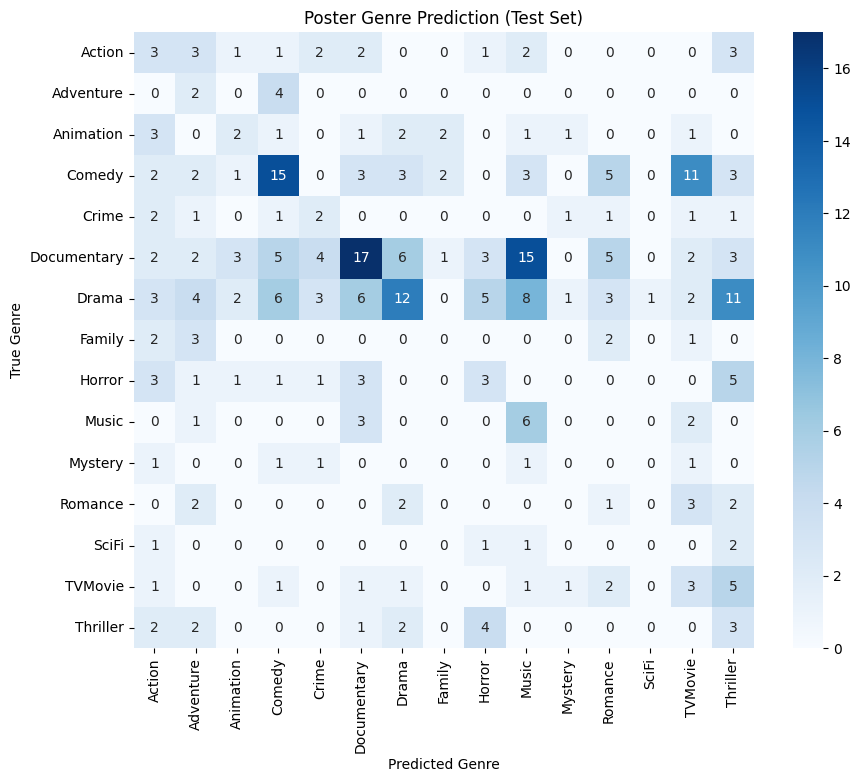

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = sorted(set(truth))

cm = confusion_matrix(truth, predictions, labels=labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Genre")
plt.ylabel("True Genre")
plt.title("Poster Genre Prediction (Test Set)")

plt.show()

In [123]:
from sklearn.feature_selection import mutual_info_classif

X = df[candidate_features].fillna(0)
y = df["genre"]

mi = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    "feature": candidate_features,
    "MI": mi
}).sort_values("MI", ascending=False)

mi_df.head(20)

,feature,MI
51,clip_prompt_scores.horror,0.152245
55,clip_prompt_scores.family_friendly,0.144183
46,clip_prompt_scores.dark_moody,0.142482
53,clip_prompt_scores.action,0.141805
57,clip_prompt_scores.sci_fi,0.123485
6,color_entropy,0.108953
31,person_count,0.102669
66,clip_prompt_scores.masked_face,0.093702
50,clip_prompt_scores.romantic,0.089044
8,neon_ratio,0.084793
